<a href="https://colab.research.google.com/github/jenyabydaev-web/homeworkk/blob/homework/Homrwork2%20(3%EC%9B%94%20%EA%B3%BC%EC%A0%9C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
# 📊 German Credit Data EDA 보고서

#본 보고서는 기술통계분석을 기반으로 신용 데이터에 대한 탐색적 데이터 분석(EDA)을 수행한다.

In [14]:
## 1. 서론 (Introduction)

### 1.1 분석 배경 및 목적
#본 분석의 목적은 고객의 신용 위험(good / bad)에 영향을 미치는 요인을 파악하는 것이다.
#이를 통해 향후 머신러닝 모델 구축을 위한 기초 데이터를 이해하고자 한다.

### 1.2 데이터 셋 설명
#- 데이터 출처: OpenML (German Credit Dataset)
#- 데이터 크기: 약 1000개 샘플
#- 변수 수: 약 20개
#- 타겟 변수: class (good / bad)

### 1.3 주요 분석 질문
#- 신용 금액은 신용 위험에 영향을 미치는가?
#- 대출 기간은 위험도와 관련이 있는가?
#- 고객의 연령 및 기타 범주형 변수는 어떤 영향을 미치는가?

In [7]:
from sklearn.datasets import fetch_openml
import pandas as pd

data = fetch_openml(name='credit-g', as_frame=True)
df = data.frame

df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [8]:
## 2. 데이터 프로파일링 (Data Profiling)

In [9]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

(1000, 21)

In [15]:
#- 데이터는 약 1000개의 행과 20개의 변수로 구성되어 있다.
#- 수치형 변수와 범주형 변수가 혼합되어 있다.

In [16]:
df.isnull().sum()

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


In [45]:
# 결측치는 존재하지 않는다.

In [18]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [46]:
# 일부 변수는 분포가 치우쳐 있으며, 이상치가 존재할 가능성이 있다.

In [20]:
## 3. 단변량 분석 (Univariate Analysis)

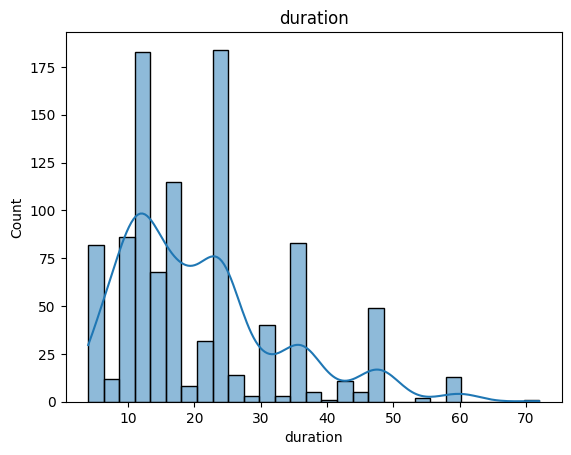

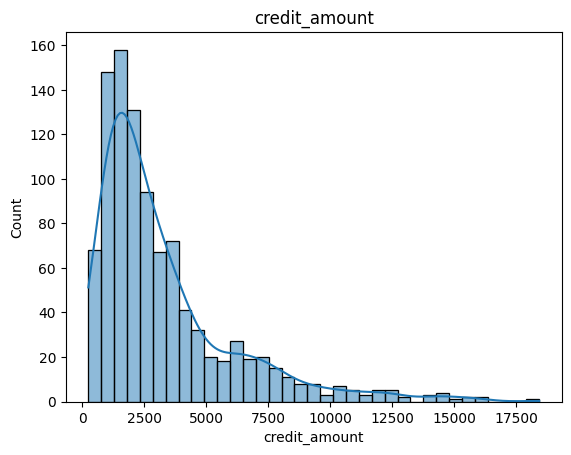

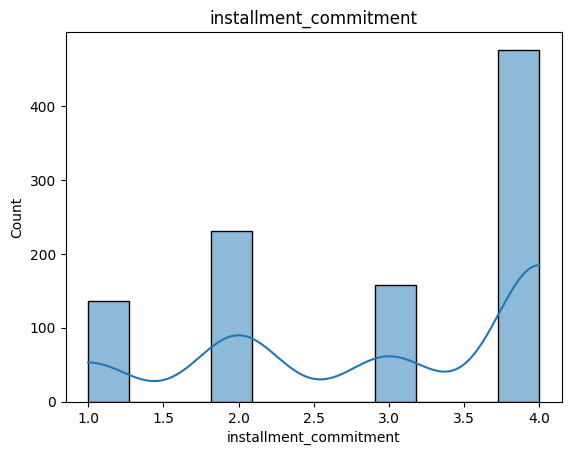

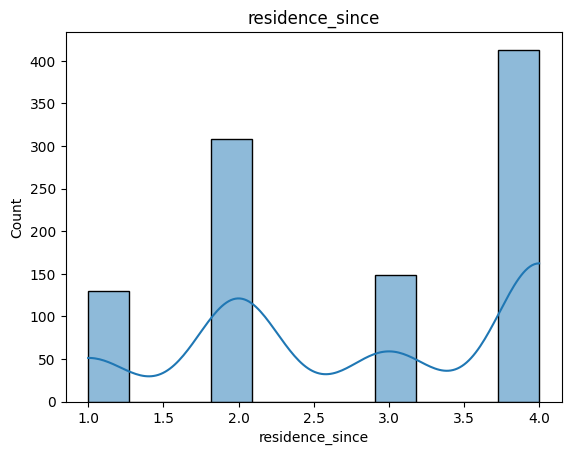

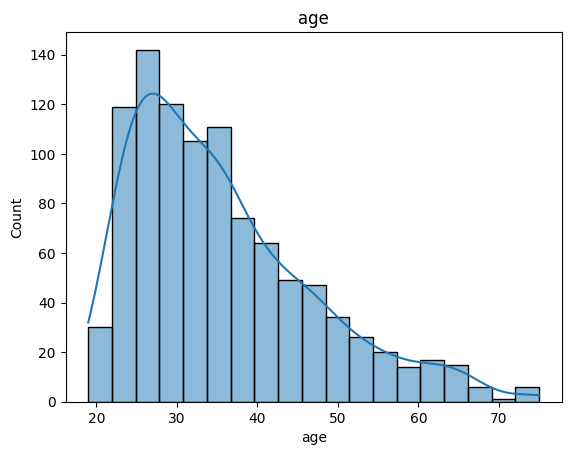

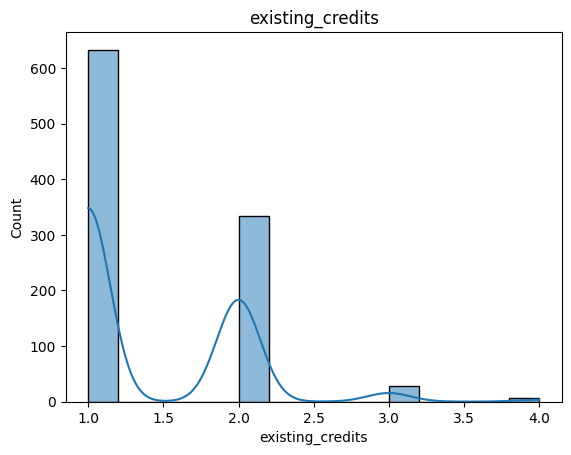

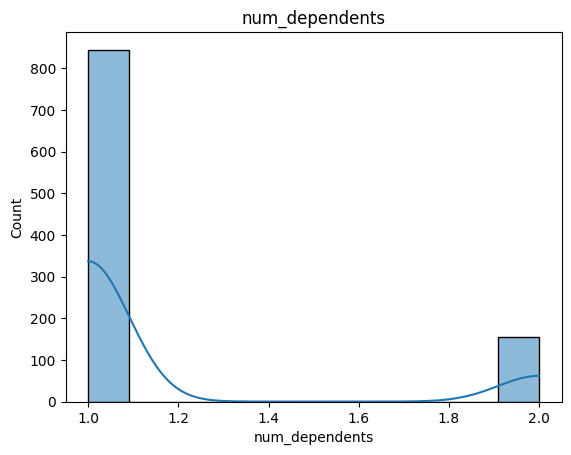

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [23]:
#- credit_amount는 오른쪽으로 치우친 분포를 보인다.
#- age는 비교적 정규분포에 가까운 형태를 가진다.

In [24]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

In [25]:
#- 일부 범주형 변수는 클래스 불균형을 보인다.
#- 희소한 카테고리 존재 가능성이 있다.

In [26]:
## 4. 다변량 분석 (Multivariate Analysis)

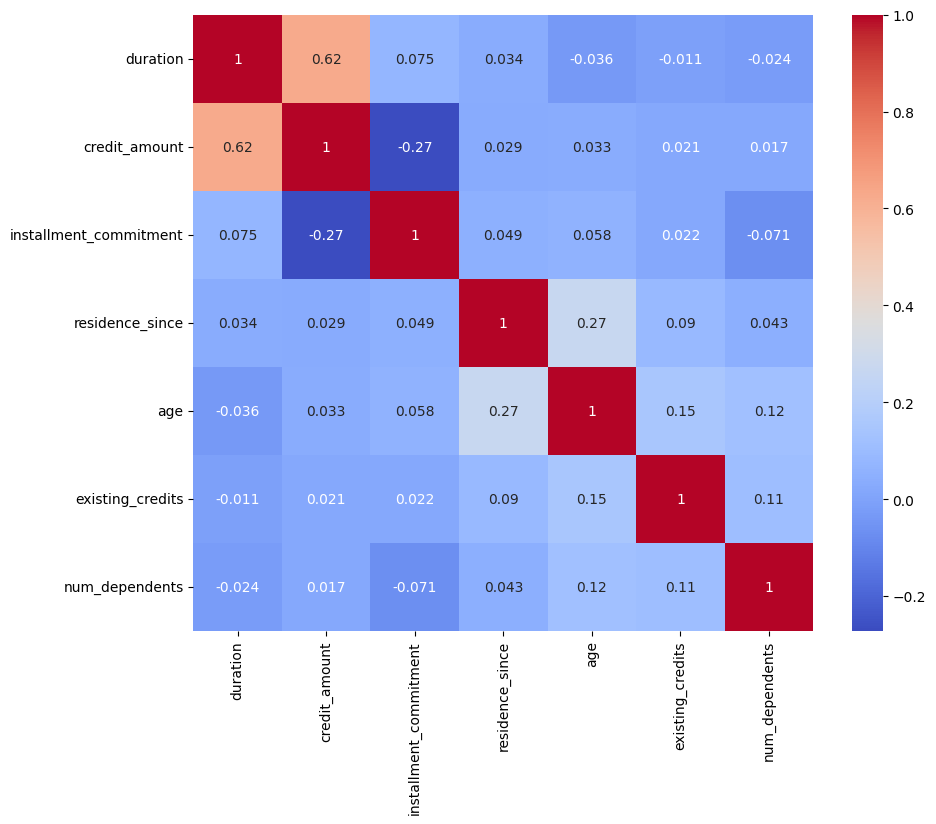

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [30]:
#- 변수 간 강한 선형 상관관계는 발견되지 않았다.
#- 다중공선성 문제는 크지 않을 것으로 판단된다.

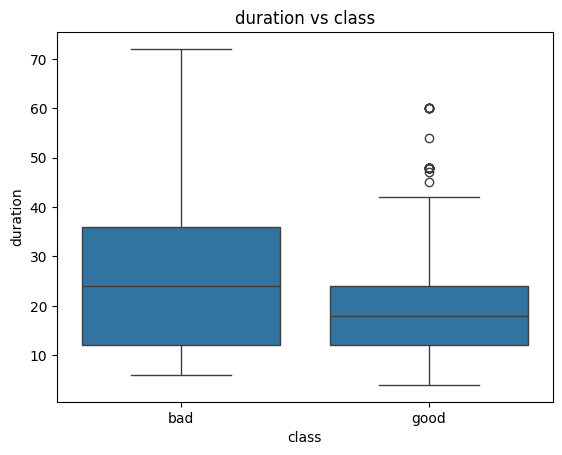

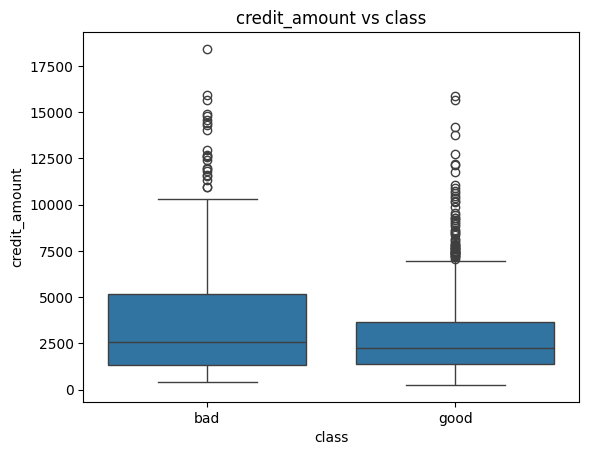

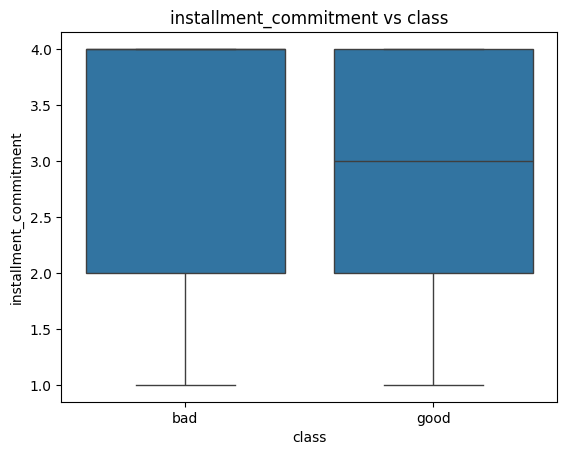

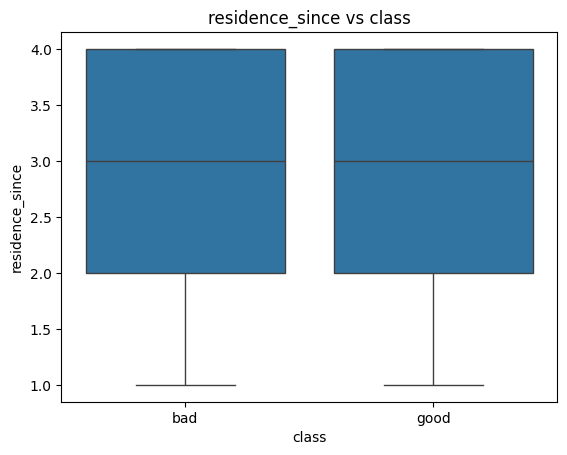

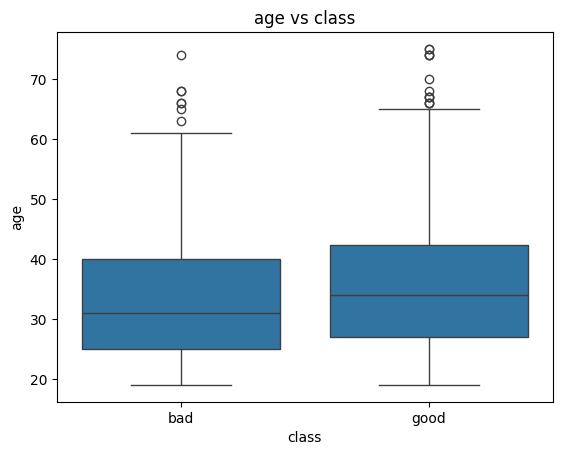

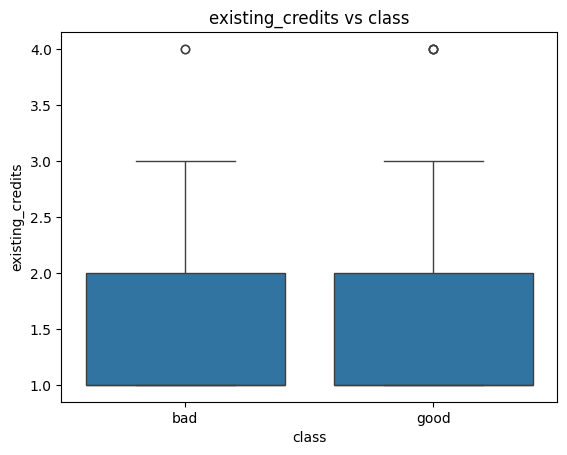

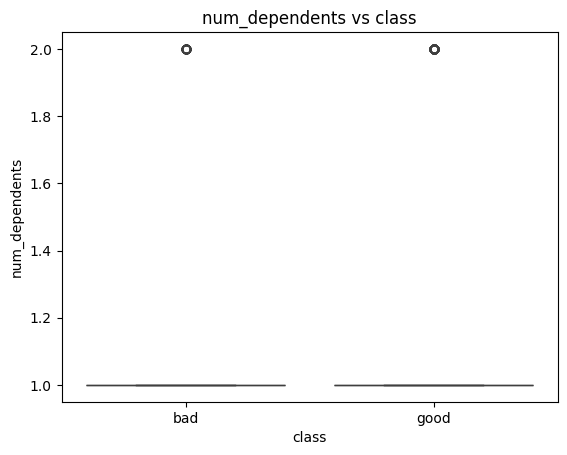

In [29]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x='class', y=col, data=df)
    plt.title(f'{col} vs class')
    plt.show()

In [31]:
#- credit_amount와 duration은 class에 따라 분포 차이를 보인다.
#- 해당 변수들은 신용 위험에 중요한 영향을 미칠 가능성이 있다.

In [37]:
## 5. 핵심 인사이트 및 가설 검증

### 5.1 주요 패턴
#- 대출 기간이 길수록 위험도가 증가하는 경향이 있다.
#- 신용 금액이 클수록 bad 클래스 비율이 증가한다.

### 5.2 가설 검증
#-  신용 금액은 영향을 미친다
#-  대출 기간은 영향을 미친다
#-  연령은 영향이 상대적으로 작다

### 5.3 예상치 못한 발견
#- 수치형 변수 간 상관관계가 낮다
#- 범주형 변수의 중요성이 높다

In [38]:
## 6. 결론 및 향후 방향

### 6.1 분석 요약
#본 분석을 통해 신용 위험은 여러 변수의 조합에 의해 결정됨을 확인하였다.

### 6.2 비즈니스 제안
#- 신용 평가 시 duration과 credit_amount를 주요 변수로 고려해야 한다.
#- 범주형 변수 활용이 중요하다.

### 6.3 한계점
#- 데이터 크기가 작다
#- 클래스 불균형 존재
#- 시간 정보가 없다

# 향후 머신러닝 모델 적용 필요 (Logistic Regression, Random Forest)

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

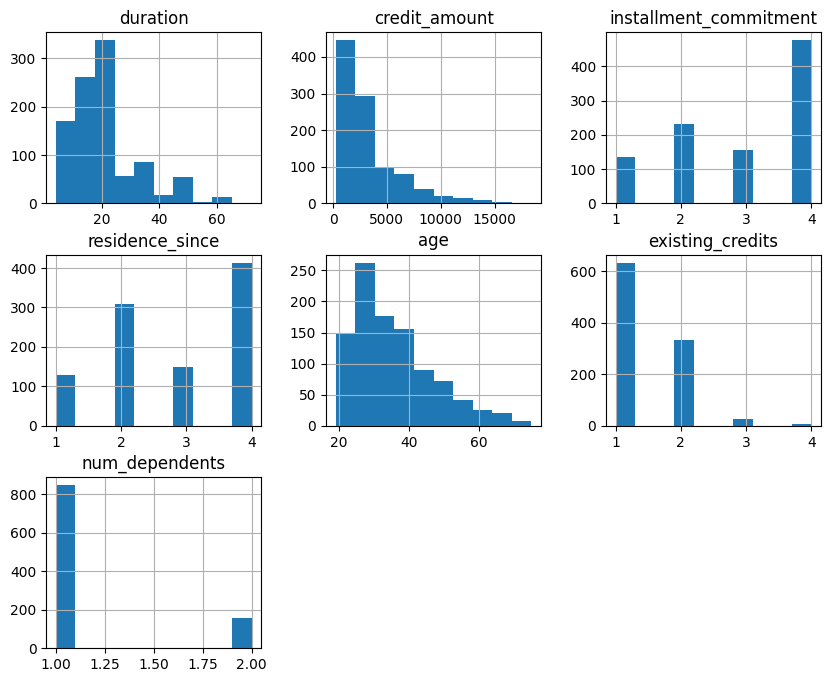

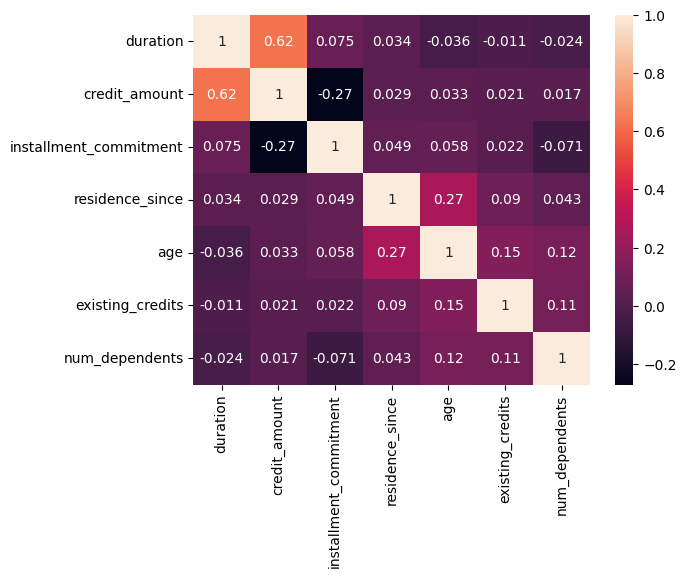

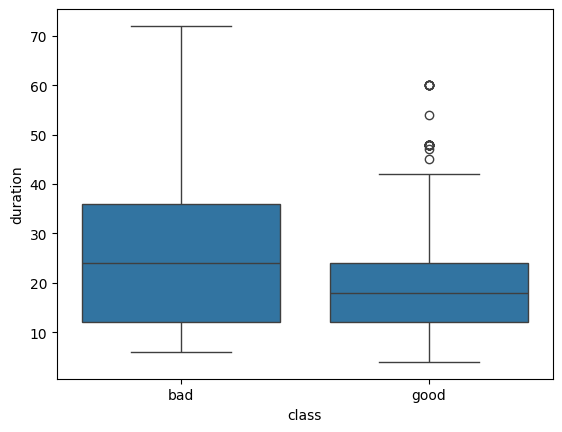

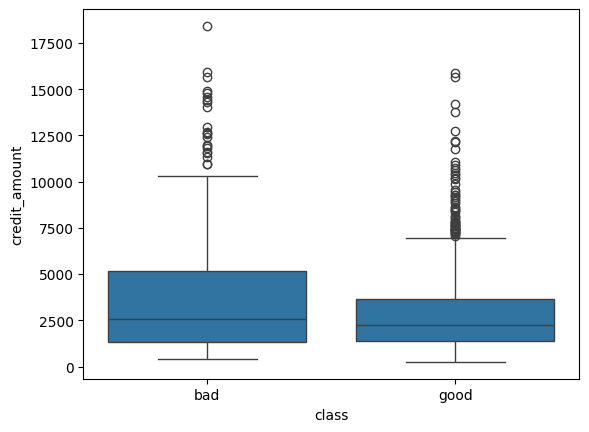

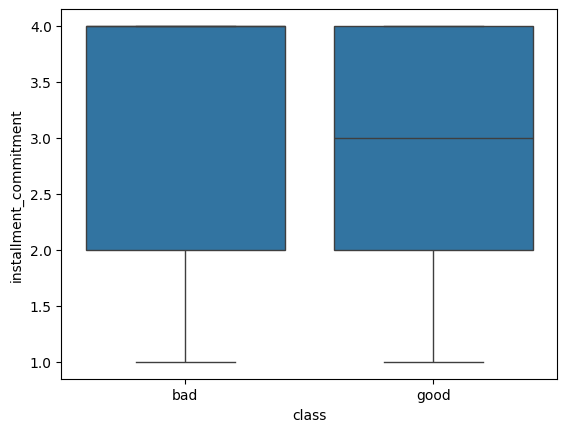

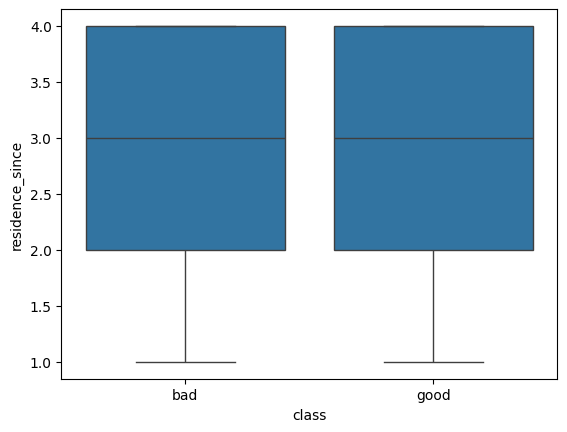

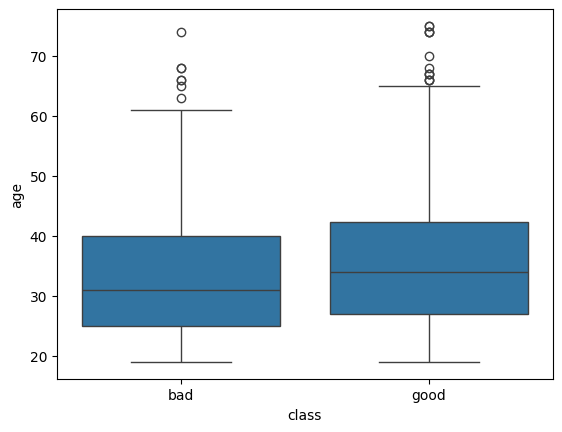

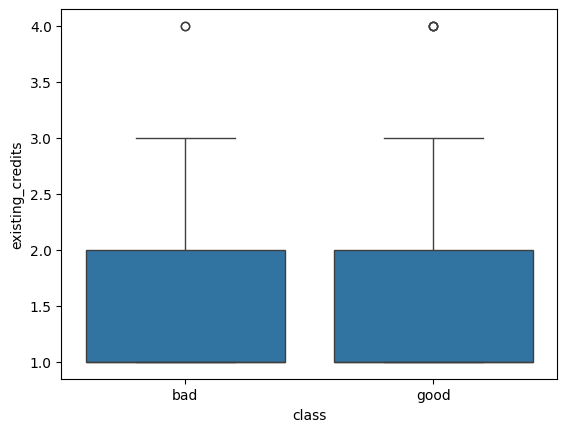

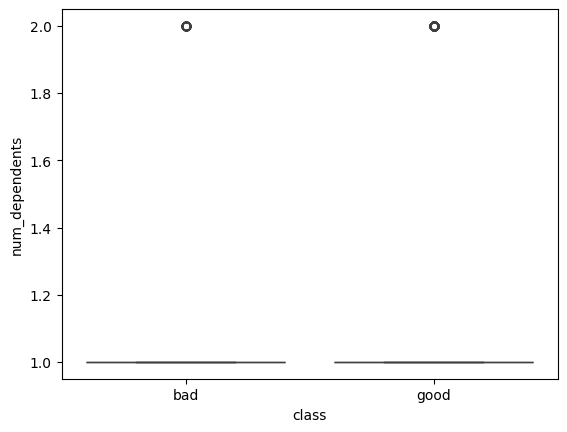

In [11]:
from sklearn.datasets import fetch_openml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = fetch_openml(name='credit-g', as_frame=True)
df = data.frame

# базовая информация
print(df.info())
print(df.describe())

# распределения
df.hist(figsize=(10,8))
plt.show()

# корреляция
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

# анализ target
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x='class', y=col, data=df)
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1

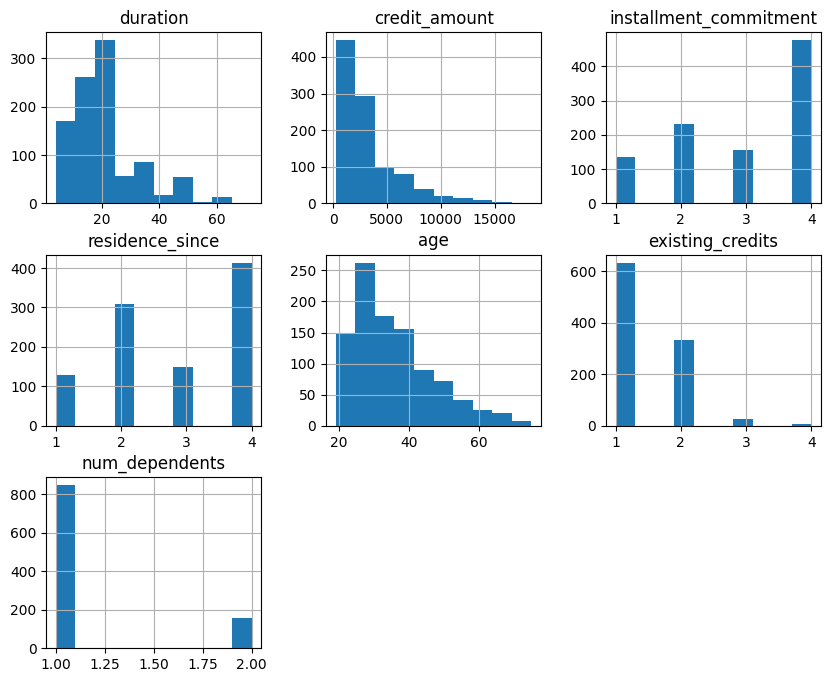

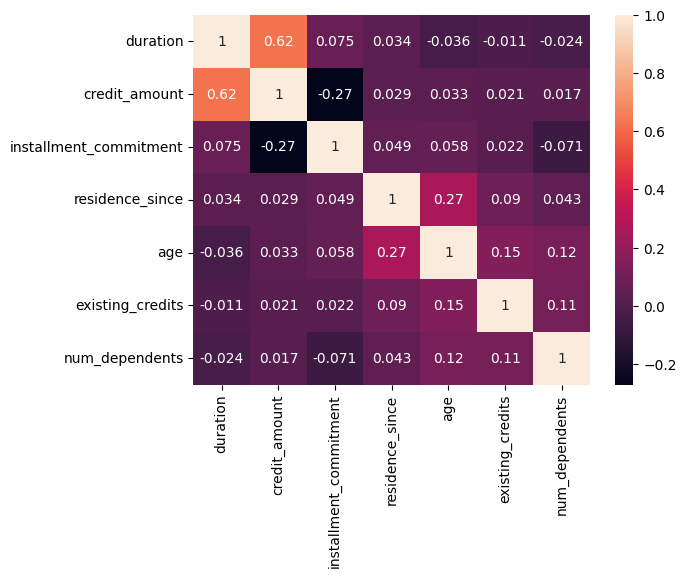

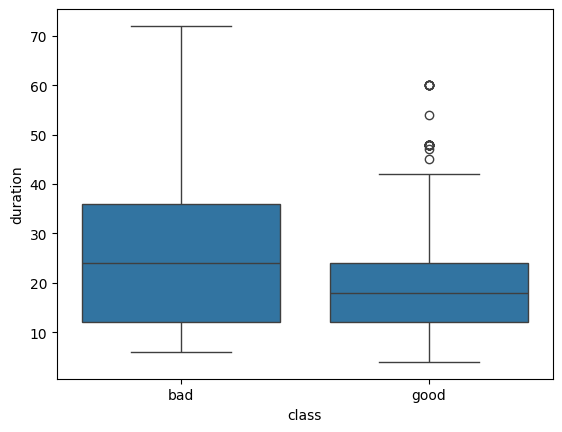

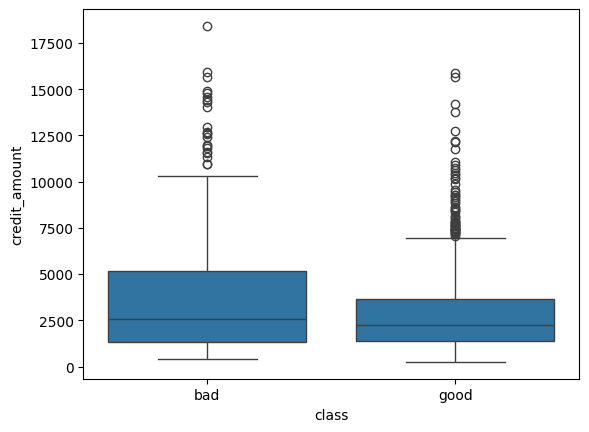

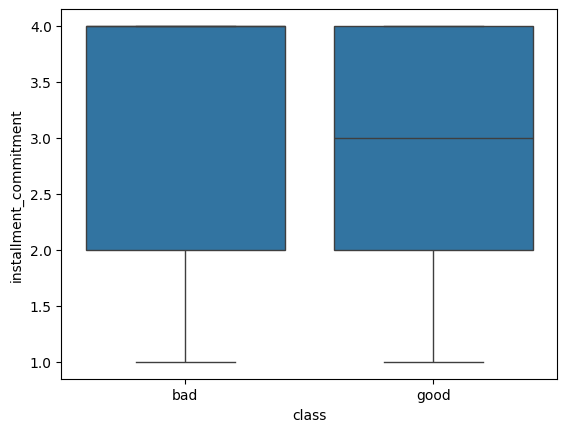

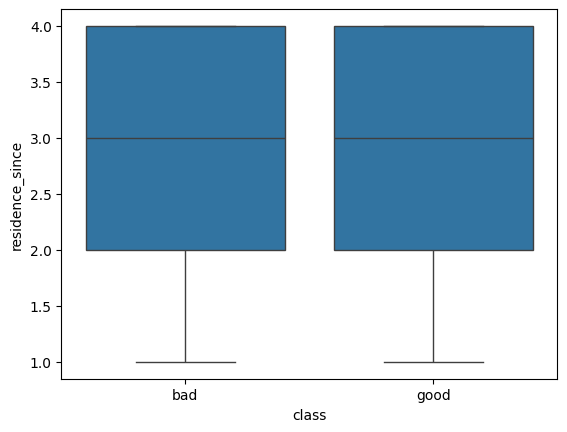

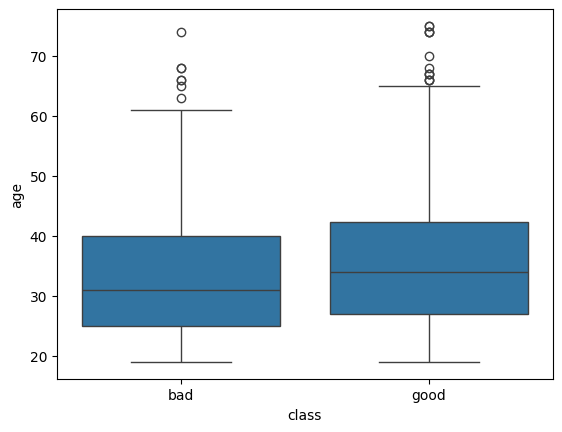

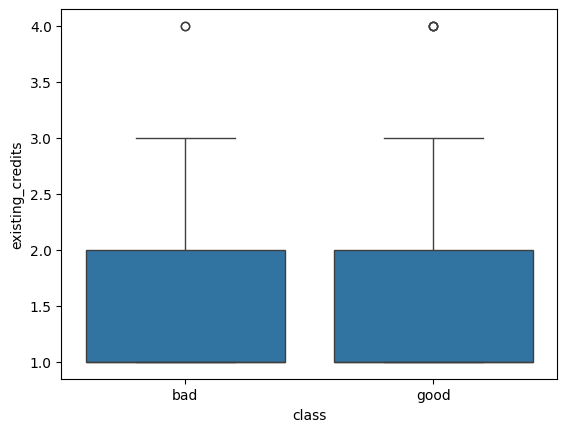

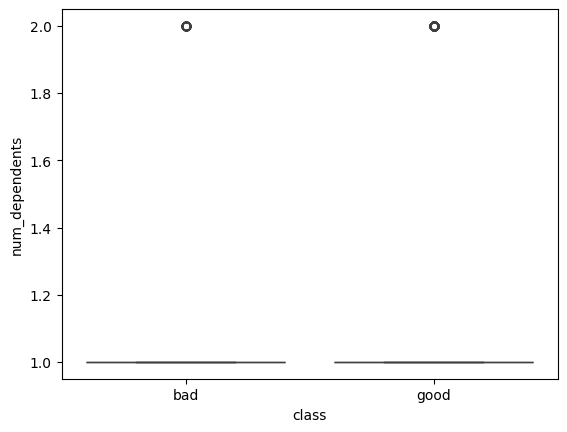

In [40]:
from sklearn.datasets import fetch_openml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = fetch_openml(name='credit-g', as_frame=True)
df = data.frame

# базовая информация
print(df.info())
print(df.describe())

# распределения
df.hist(figsize=(10,8))
plt.show()

# корреляция
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

# анализ target
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x='class', y=col, data=df)
    plt.show()

In [43]:
#German Credit 데이터 분석 보고서 (EDA)
#1. 데이터 개요 및 가설 설정
#데이터 설명: 독일 은행의 고객 데이터를 바탕으로 대출 고객의 신용 등급(Good/Bad)을 분류한 데이터입니다.

#분석 목적: 고객의 인구통계학적 특성(나이, 직업 등)과 금융 상태(잔고, 대출 금액 등)가 신용 등급에 미치는 영향을 파악합니다.

#가설 설정:

#예금 잔고가 많을수록 신용 등급이 'Good'일 확률이 높을 것이다.

#대출 금액(credit_amount)이 클수록 상환 부담으로 인해 'Bad' 등급의 비율이 높을 것이다.

#고용 기간이 길수록 신용 상태가 안정적일 것이다.